In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import math
import numpy as np
from matplotlib.ticker import LogFormatterMathtext, FixedLocator, FuncFormatter

In [2]:
v1 = pd.read_csv("../results/timings/simulation_timings_naive.csv")
v2 = pd.read_csv("../results/timings/simulation_timings_optimized.csv")

output = (
    pd.concat([v1, v2], keys=["naive", "optimized"])
    .reset_index(level=0)
    .rename(columns={"level_0": "implementation"})
)

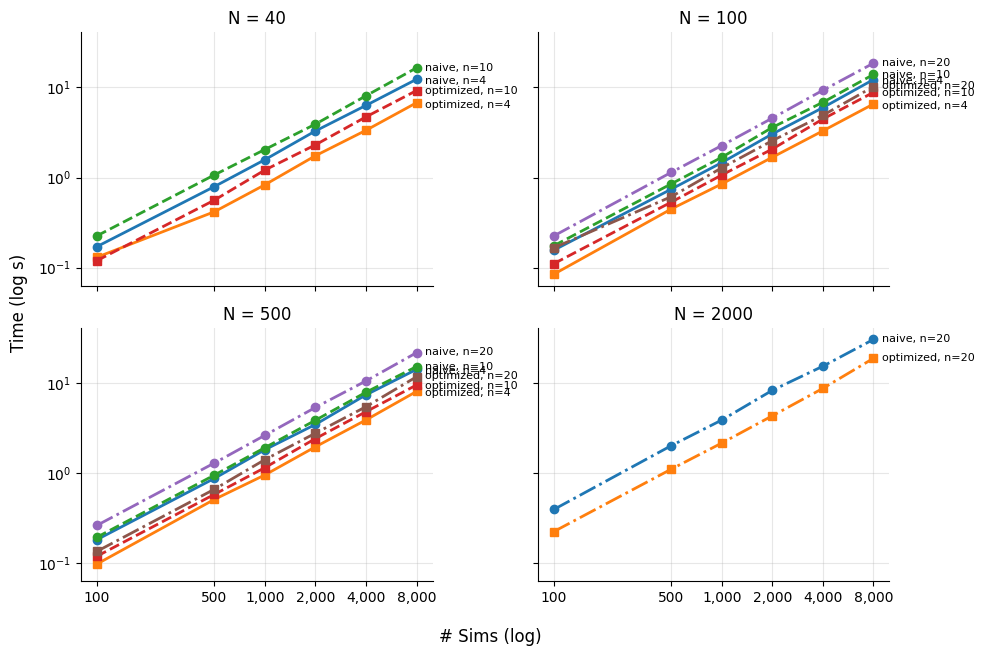

In [3]:
# ChatGPT helped with this plotting
# === config ===
row_var = "N"  # facets
col_var = "n"  # linestyle
impl_var = "implementation"  # color+marker
x_max_pad = None  # e.g., 4000 to extend to the right; or None

# ---- levels ----
row_vals = sorted(output[row_var].unique())
col_vals = sorted(output[col_var].unique())
impl_levels = sorted(output[impl_var].unique(), key=lambda s: str(s).lower())

# ---- styles ----
linestyles = ["solid", "dashed", "dashdot", "dotted"]
ls_map = {cv: linestyles[i % len(linestyles)] for i, cv in enumerate(col_vals)}
markers = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]
impl_mark = {impl: markers[i % len(markers)] for i, impl in enumerate(impl_levels)}


def label_right(ax, x, y, text, dy=0.0):
    xmin, xmax = ax.get_xlim()
    dx = 0.02 * (xmax - xmin) if xmax > xmin else 0.0
    ax.text(x + dx, y * (1 + dy), f"  {text}", va="center", fontsize=8, clip_on=False)


# paginate into 2x2
panels_per_fig = 4
num_pages = math.ceil(len(row_vals) / panels_per_fig)

for page in range(num_pages):
    rows_this_page = row_vals[page * panels_per_fig : (page + 1) * panels_per_fig]

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
    axes = np.array(axes).reshape(2, 2)

    seen_cols = set()
    page_df = output[output[row_var].isin(rows_this_page)]

    # union of x levels on this page (we'll use these as log-x ticks & labels)
    x_levels = sorted(page_df["n_sim"].unique())

    for k, rv in enumerate(rows_this_page):
        i, j = divmod(k, 2)
        ax = axes[i, j]

        sub_r = output[output[row_var] == rv].copy()
        ax.set_title(f"{row_var} = {rv}")

        sub_r.sort_values(["n_sim", impl_var, col_var], inplace=True)

        for cv in col_vals:
            sub_rc = sub_r[sub_r[col_var] == cv]
            if sub_rc.empty:
                continue
            seen_cols.add(cv)
            dy = (list(ls_map.values()).index(ls_map[cv]) - 1.5) * 0.03

            for impl, group in sub_rc.groupby(impl_var):
                group = group.sort_values("n_sim")
                ax.plot(
                    group["n_sim"],
                    group["time_seconds"],
                    linestyle=ls_map[cv],
                    marker=impl_mark[impl],
                    linewidth=2,
                )
                x_end = group["n_sim"].iloc[-1]
                y_end = group["time_seconds"].iloc[-1]
                label_right(ax, x_end, y_end, f"{impl}, {col_var}={cv}", dy=dy)

        # ---- LOG X-AXIS with original-number labels ----
        ax.set_xscale("log")
        ax.xaxis.set_major_locator(FixedLocator(x_levels))  # ticks at your n_sim values
        ax.xaxis.set_major_formatter(
            FuncFormatter(
                lambda v, pos: f"{int(v):,}"
                if v in x_levels
                else ""  # 100, 500, 1,000, 2,000 …
            )
        )
        # kill minor ticks on x to reduce clutter
        ax.tick_params(axis="x", which="minor", bottom=False)

        if x_max_pad is not None and len(x_levels):
            ax.set_xlim(min(x_levels), x_max_pad)

    # hide unused panels
    if len(rows_this_page) < panels_per_fig:
        for k in range(len(rows_this_page), panels_per_fig):
            i, j = divmod(k, 2)
            axes[i, j].axis("off")

    # ---- LOG Y-AXIS with decade ticks only ----
    y_all = page_df["time_seconds"]
    y_all = y_all[y_all > 0]
    if len(y_all):
        decade_lo = int(np.floor(np.log10(y_all.min())))
        decade_hi = int(np.ceil(np.log10(y_all.max())))
        major_ticks = 10.0 ** np.arange(decade_lo, decade_hi + 1)
    else:
        major_ticks = 10.0 ** np.arange(-1, 4)

    for ax in axes.ravel():
        if not ax.has_data():
            continue
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(FixedLocator(major_ticks))
        ax.yaxis.set_major_formatter(LogFormatterMathtext())
        # only major gridlines
        ax.minorticks_off()
        ax.grid(True, which="major", alpha=0.30)
        ax.grid(False, which="minor")
        # clean frame + room for labels
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.margins(x=0.05)

    # shared labels
    fig.supxlabel("# Sims (log)")
    fig.supylabel("Time (log s)")

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

In [21]:
import os
import re
import pstats
import pandas as pd


# ChatGPT generated code for combining dataframes together. Seems to work
# without issue and does everything I need. I've edited some parts to simplify.


# ---------- 1) Loader: .prof/.pstats -> tidy DataFrame ----------
def profile_to_df(src, strip_dirs=True):
    """
    src: path to .prof file OR an existing pstats.Stats object.
    Returns a tidy DataFrame with a stable 'func_key'.
    """
    st = pstats.Stats(src) if isinstance(src, (str, os.PathLike)) else src
    if strip_dirs:
        st.strip_dirs()

    def func_key(func_tuple, include_line=True):
        filename, lineno, funcname = func_tuple
        # normalize filename -> module-ish name
        if filename.startswith("{built-in"):
            base = "builtins"
        else:
            base = os.path.basename(filename) if strip_dirs else filename
            base = re.sub(r"\.pyc?$", "", base)
        return f"{base}:{funcname}:{lineno}" if include_line else f"{base}:{funcname}"

    rows = []
    for func, (cc, nc, tt, ct, callers) in st.stats.items():
        filename, lineno, funcname = func
        rows.append(
            {
                "file": os.path.basename(filename) if strip_dirs else filename,
                "line": lineno,
                "func": funcname,
                "func_key": func_key(
                    func, include_line=False
                ),  # stable join key (file:func:line)
                "ncalls": nc,  # total calls (incl. recursion)
                "ccalls": cc,  # primitive calls
                "tottime": tt,  # time in function body (excl. subcalls)
                "cumtime": ct,  # incl. subcalls
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # convenience cols
    df = df.groupby("func_key").sum()
    df["tottime_pct"] = df["tottime"] / df["tottime"].sum()
    df["cumtime_pct"] = df["cumtime"] / df["cumtime"].sum()
    return df.sort_values("tottime_pct", ascending=False).reset_index(drop=False)

In [23]:
df1, df2 = (
    profile_to_df("../results/timings/profile_naive.prof"),
    profile_to_df("../results/timings/profile_optimized.prof"),
)
df1.sort_values("tottime", ascending=False).head(10)

,func_key,file,line,func,ncalls,ccalls,tottime,cumtime,tottime_pct,cumtime_pct
0,<frozen importlib._bootstrap_external>:find_spec,<frozen importlib._bootstrap_external><frozen ...,3175,find_specfind_spec,7564588,7564588,15.611928,101.719829,0.046891,0.021134
1,<frozen importlib._bootstrap_external>:_path_join,<frozen importlib._bootstrap_external>,131,_path_join,32414575,32414575,11.221816,19.232158,0.033705,0.003996
2,naive_methods:fit_parametricEB,naive_methods.py,60,fit_parametricEB,72003,72003,9.795491,25.160620,0.029421,0.005228
3,arrayprint:recurser,arrayprint.py,851,recurser,13272015,72003,9.521435,30.849993,0.028598,0.006410
4,~:<built-in method posix.stat>,~,0,<built-in method posix.stat>,6487202,6487202,9.323108,9.323108,0.028002,0.001937
5,naive_dgps:generate_design_matrix,naive_dgps.py,195,generate_design_matrix,72717,72717,7.631296,15.111529,0.022921,0.003140
6,~:<built-in method builtins.len>,~,0,<built-in method builtins.len>,137776000,130645733,7.533429,8.512397,0.022627,0.001769
7,_linalg:inv,_linalg.py,557,inv,1733077,1733077,6.864124,13.400961,0.020617,0.002784
8,arrayprint:__call__,arrayprint.py,1092,__call__,12384012,12384012,6.583342,8.970615,0.019773,0.001864
9,arrayprint:<genexpr>,arrayprint.pyarrayprint.pyarrayprint.pyarraypr...,4248,<genexpr><genexpr><genexpr><genexpr>,49824060,49824060,6.208970,13.544933,0.018649,0.002814


In [28]:
key_funcs = [
    "generate_design_matrix",
    "fit_mle",
    "fit_semiBayes",
    "fit_parametricEB",
    "recurser",
    "_path_join",
    "find_specified_spec",
    "inv",
    "solve",
]
comparison = pd.merge(
    df1[df1["func"].isin(key_funcs)][["func", "tottime", "cumtime"]],
    df2[df2["func"].isin(key_funcs)][["func", "tottime", "cumtime"]],
    on="func",
    suffixes=("_v1", "_v2"),
    how="outer",
)

comparison["tottime_diff"] = comparison["tottime_v2"] - comparison["tottime_v1"]
print(
    comparison.sort_values("tottime_diff", ascending=False)[
        ["func", "tottime_v1", "tottime_v2", "tottime_diff"]
    ]
    .reset_index(drop=True)
    .to_markdown()
)

|    | func                   |   tottime_v1 |   tottime_v2 |   tottime_diff |
|---:|:-----------------------|-------------:|-------------:|---------------:|
|  0 | fit_mle                |     0.220693 |   2.4477     |       2.22701  |
|  1 | fit_semiBayes          |     5.19168  |   5.54593    |       0.354247 |
|  2 | solve                  |     2.5711   |   2.24997    |      -0.321129 |
|  3 | generate_design_matrix |     7.6313   |   7.19122    |      -0.44008  |
|  4 | fit_parametricEB       |     9.79549  |   6.81113    |      -2.98436  |
|  5 | inv                    |     6.86412  |   1.2375e-05 |      -6.86411  |
|  6 | recurser               |     9.52143  |   2.854e-05  |      -9.52141  |
|  7 | _path_join             |    11.2218   |   0.00589818 |     -11.2159   |


In [24]:
df1[df1["func"].isin(key_funcs)]

,file,line,func,func_key,ncalls,ccalls,tottime,cumtime,percall_tottime,percall_cumtime,tottime_pct,cumtime_pct
19,methods.py,28,fit_mle,methods:fit_mle,72732,72732,0.160261,47.125431,2.203452e-06,6.479326e-04,0.000615,0.012753
42,arrayprint.py,851,recurser,arrayprint:recurser,13272015,72003,7.734119,25.235592,5.827389e-07,1.901414e-06,0.029687,0.006829
45,methods.py,60,fit_parametricEB,methods:fit_parametricEB,72006,72006,7.687010,19.916602,1.067551e-04,2.765964e-04,0.029506,0.005390
52,<frozen importlib._bootstrap_external>,131,_path_join,<frozen importlib._bootstrap_external>:_path_join,27013538,27013538,7.877644,13.275429,2.916184e-07,4.914361e-07,0.030238,0.003593
53,methods.py,177,fit_semiBayes,methods:fit_semiBayes,216010,216010,4.247639,12.661412,1.966408e-05,5.861494e-05,0.016304,0.003427
57,dgps.py,195,generate_design_matrix,dgps:generate_design_matrix,72732,72732,6.190427,12.031995,8.511283e-05,1.654292e-04,0.023762,0.003256


In [25]:
df2[df2["func"].isin(key_funcs)]

,file,line,func,func_key,ncalls,ccalls,tottime,cumtime,percall_tottime,percall_cumtime,tottime_pct,cumtime_pct
6,methods.py,26,fit_mle,methods:fit_mle,72916,72916,1.823149,71.062921,2.500342e-05,9.745861e-04,1.478632e-02,4.299108e-02
22,methods.py,59,fit_parametricEB,methods:fit_parametricEB,72000,72000,5.227119,12.350260,7.259887e-05,1.715314e-04,4.239359e-02,7.471562e-03
23,methods.py,184,fit_semiBayes,methods:fit_semiBayes,216000,216000,4.401580,10.904755,2.037768e-05,5.048498e-05,3.569821e-02,6.597071e-03
32,dgps.py,193,generate_design_matrix,dgps:generate_design_matrix,72916,72916,5.737134,6.964450,7.868141e-05,9.551333e-05,4.652998e-02,4.213297e-03
550,<frozen importlib._bootstrap_external>,131,_path_join,<frozen importlib._bootstrap_external>:_path_join,12837,12837,0.004725,0.007968,3.680668e-07,6.207149e-07,3.832023e-05,4.820488e-06
1921,arrayprint.py,851,recurser,arrayprint:recurser,15,3,0.000023,0.000054,1.530800e-06,3.597200e-06,1.862291e-07,3.264308e-08
